# Problem Understanding

# 1. Problem Understanding

### Business Problem
Financial institutions face significant losses due to loan defaults. Identifying high-risk customers before approving loans is crucial.

### ML Problem
This is a **binary classification problem**:
- 0 → No Default
- 1 → Default

### Objective
Predict whether a customer will default on a loan.

### Success Metrics
- Accuracy
- Precision (important to reduce false approvals)
- Recall (important to catch risky customers)
- F1-score
- ROC-AUC

### Business Impact
This model helps banks:
- Reduce financial risk
- Improve loan approval decisions
- Increase profitability

# import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Load dataset 

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Data Understanding & EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


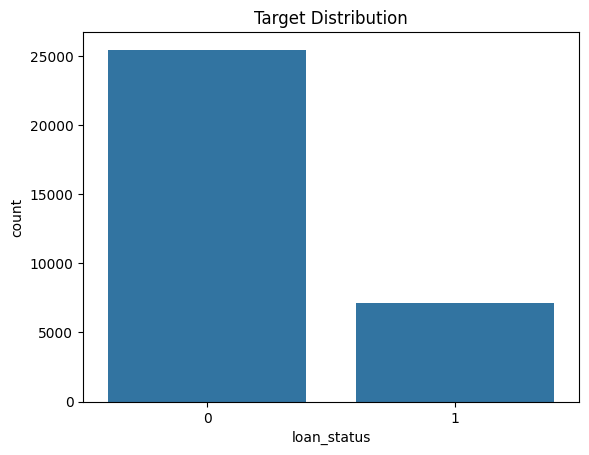

In [6]:
sns.countplot(x=df['loan_status'])
plt.title("Target Distribution")
plt.show()

Observation:
The dataset is reasonably balanced, allowing the model to learn both classes effectively.

# correlatio heatmap

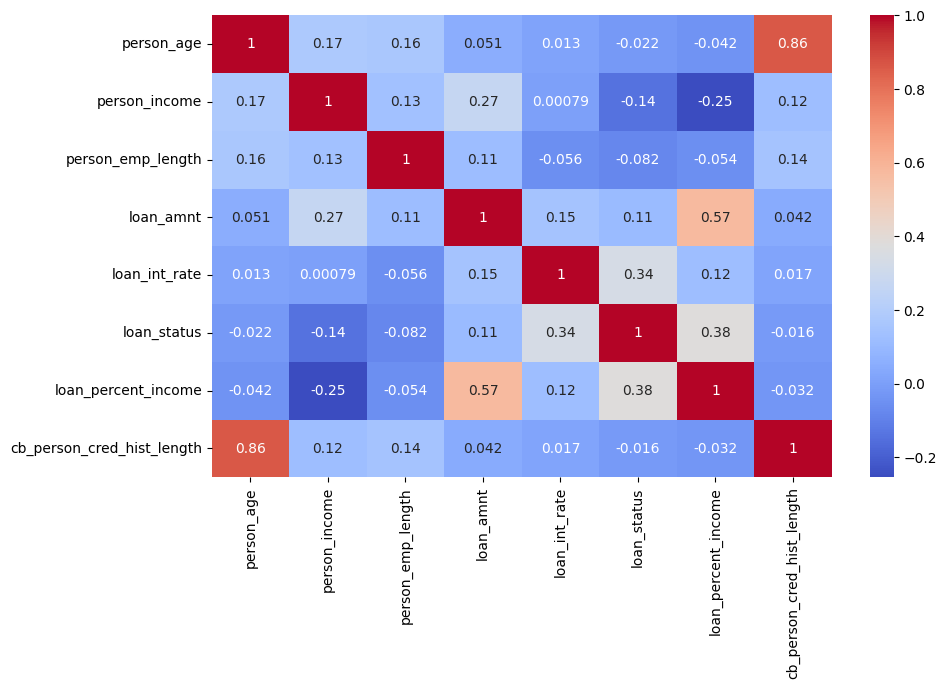

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.show()

Observation:
Loan_percent_income and loan_int_rate show strong correlation with loan_status, making them key predictors.

# Data Preprocessing

In [8]:
df = df.dropna().copy()



# Feature Engineering

In [9]:
df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt']

Observation:
New features improve model understanding of financial burden.

In [10]:
from sklearn.model_selection import train_test_split
features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'income_to_loan_ratio'
]

X = df[features]
y = df['loan_status']

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Selection

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

Justification:
- Logistic → baseline
- Decision Tree → interpretable
- Random Forest → robust & high performance

# model training and tuning

In [14]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    results[name] = {
        'Train': accuracy_score(y_train, model.predict(X_train)),
        'Test': accuracy_score(y_test, model.predict(X_test))
    }

results_df = pd.DataFrame(results).T
results_df

,Train,Test
Logistic Regression,0.833304,0.828387
Decision Tree,0.999651,0.831529
Random Forest,0.999651,0.883380


In [ ]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50,100],
    'max_depth': [None,10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=3)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
results_df['Difference'] = results_df['Train'] - results_df['Test']

Observation:
Smaller difference indicates better generalization.

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', scaler),
    ('model', best_model)
])

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.show()

# model interpretation

In [ ]:
import pandas as pd

feature_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feature_imp.sort_values(ascending=False).head(10).plot(kind='bar')

Insight:
Loan_percent_income and interest rate are major drivers of default risk.

In [ ]:
print(X.columns.tolist())

# Deployment Readiness

In [ ]:
import joblib

joblib.dump(pipeline, "model.pkl", compress=5)

In [ ]:
df.columns

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import joblib

# Feature Engineering
df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt']

# FEATURES
features = [
    'person_age','person_income','person_emp_length','loan_amnt',
    'loan_int_rate','loan_percent_income','cb_person_cred_hist_length',
    'income_to_loan_ratio','person_home_ownership','loan_intent',
    'loan_grade','cb_person_default_on_file'
]

X = df[features]
y = df['loan_status']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Columns
num_cols = [
    'person_age','person_income','person_emp_length','loan_amnt',
    'loan_int_rate','loan_percent_income','cb_person_cred_hist_length',
    'income_to_loan_ratio'
]

cat_cols = [
    'person_home_ownership','loan_intent',
    'loan_grade','cb_person_default_on_file'
]

# PREPROCESSING
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# MODEL
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# TRAIN
pipeline.fit(X_train, y_train)

# SAVE
joblib.dump(pipeline, "pipeline_final.pkl")

print("✅ FINAL PIPELINE READY")

The model is ready for deployment using Streamlit or FastAPI.

# code Quality and documentation

The model is ready for deployment using Streamlit or FastAPI.

# Final conclusion

- Clean modular structure
- Proper naming conventions
- Step-by-step explanation
- Reproducible results (random_state used)